In [1]:
import torch
import os
import gc
from engineering_notation import EngNumber
import matplotlib.pyplot as plt
from icecream import ic
torch.cuda.empty_cache()

In [ ]:
torch.manual_seed(100)

torch.cuda.empty_cache()
N=10_000_000
name=EngNumber(N)

root="DataForDecays"

os.makedirs("DataForDecays/",exist_ok=True)

def counts():
    justA=torch.rand(size=(N,1),device="cuda")
    mask=justA<=0.99987
    invmask=~mask
    meanMa=139.57018
    stdMa=0.00035
    mA=torch.normal(size=(N,1),mean=meanMa,std=stdMa,device="cuda")

    mB=torch.ones_like(justA,device="cuda")
    mB[mask]=105.66
    mB[invmask]=0.510

    mC=torch.zeros_like(justA,device="cuda")
    del justA
    N_local = mA.shape[0]
    device = mA.device
    def findingMomentum(mP,mD1,mD2):
        mA, mB, mC=mP,mD1,mD2
        arg = (mA**2-(mB+mC)**2)*(mA**2 - (mB-mC)**2)
        arg = torch.clamp(arg, min=0)
        momentum = 1/(2*mA)*torch.sqrt(arg)
        return momentum
    momentum=findingMomentum(mA,mB,mC)

    randMom = torch.distributions.Exponential(1/150).sample((N_local,1)).cuda()
    pionMomentumCountBins=torch.histc(randMom,bins=250,min=0,max=500)
    beta=randMom/torch.sqrt(mA**2+randMom**2)
    del randMom,mA
    beta = torch.clamp(beta, max=0.999999)
    x = torch.rand((N_local,1), device=device)*2 - 1
    x = torch.clamp(x, -1, 1)
    theta = torch.arccos(x)
    del x
    EB = torch.sqrt(momentum**2 + mB**2)
    EC = torch.sqrt(momentum**2 + mC**2)
    gamma = 1 / torch.sqrt(1 - beta**2)
    pcThetas=momentum*torch.cos(theta)
    psThetas=momentum*torch.sin(theta)
    thetaDashB = torch.arctan2(psThetas, gamma*(pcThetas + beta*EB))/torch.pi*180
    pB_parallel = gamma*(pcThetas + beta*EB)
    pB_perp     = psThetas

    pC_parallel = gamma*(-pcThetas + beta*EC)
    pC_perp     = -psThetas

    dot = pB_parallel * pC_parallel + pB_perp * pC_perp

    magB = torch.sqrt(pB_parallel**2 + pB_perp**2)
    magC = torch.sqrt(pC_parallel**2 + pC_perp**2)

    cos_angle = dot / (magB * magC)
    cos_angle = torch.clamp(cos_angle, -1.0, 1.0)

    opening_angle = torch.arccos(cos_angle) / torch.pi * 180




    magMomB=torch.sqrt((psThetas)**2+ (gamma*(pcThetas + beta*EB))**2)
    thetaDashC = torch.abs(torch.arctan2(-psThetas, gamma*(-pcThetas + beta*EC)))/torch.pi*180
    
    magMomC=torch.sqrt((-psThetas)**2+ (gamma*(-pcThetas + beta*EC))**2)
    print(magMomC.max(),magMomB.max())

    theta=theta/torch.pi*180
    thetaCountBins=torch.histc(theta,bins=100,min=0,max=180)
    del theta
    thetadashBcountBins1=torch.histc(thetaDashB[mask],bins=100,min=0,max=180)
    MomentumBcountBins1=torch.histc(magMomB[mask],bins=100,min=0,max=200)
    thetadashCcountBins1=torch.histc(thetaDashC[mask],bins=100,min=0,max=180)
    MomentumCcountBins1=torch.histc(magMomC[mask],bins=100,min=0,max=200)
    MomentumCountBins1=torch.histc(momentum[mask],bins=100,min=0,max=200)
    thetadashBcountBins2=torch.histc(thetaDashB[invmask],bins=100,min=0,max=180)
    MomentumBcountBins2=torch.histc(magMomB[invmask],bins=100,min=0,max=200)
    thetadashCcountBins2=torch.histc(thetaDashC[invmask],bins=100,min=0,max=180)
    MomentumCcountBins2=torch.histc(magMomC[invmask],bins=100,min=0,max=200)
    MomentumCountBins2=torch.histc(momentum[invmask],bins=100,min=0,max=200)

    del thetaDashB, thetaDashC, magMomB, magMomC,
    MomentumBcountBins=[MomentumBcountBins1,MomentumBcountBins2]
    thetadashBcountBins=[thetadashBcountBins1,thetadashBcountBins2]
    MomentumCcountBins=[MomentumCcountBins1,MomentumCcountBins2]
    thetadashCcountBins=[thetadashCcountBins1,thetadashCcountBins2]
    MomentumCountBins=[MomentumCountBins1,MomentumCountBins2]
    thetaDifferenceCountbins1 = torch.histc(opening_angle[mask], bins=100, min=0, max=180)
    thetaDifferenceCountbins2 = torch.histc(opening_angle[invmask], bins=100, min=0, max=180)
    thetaDifferenceBins=[thetaDifferenceCountbins1,thetaDifferenceCountbins2]
    #              a               b                     c                    d                   e                     f          g                    h
    return MomentumCcountBins,pionMomentumCountBins,thetadashBcountBins,MomentumBcountBins,thetadashCcountBins,MomentumCountBins,thetaCountBins,thetaDifferenceBins

def getBinCenters(min_val, max_val, bins):
    edges = torch.linspace(min_val, max_val, bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers

thetaBincenters=getBinCenters(0,180,100)
DaughterMomentumBincenters=getBinCenters(0,200,100)
ParentMomentumBincenters=getBinCenters(0,500,250)


a0,b0,c0,d0,e0,f0,g0,h0 = counts()

for _ in range(50):
    a1,b1,c1,d1,e1,f1,g1,h1 = counts()
    a0 = [a0[0] + a1[0], a0[1] + a1[1]]
    c0 = [c0[0] + c1[0], c0[1] + c1[1]]
    d0 = [d0[0] + d1[0], d0[1] + d1[1]]
    e0 = [e0[0] + e1[0], e0[1] + e1[1]]
    f0 = [f0[0] + f1[0], f0[1] + f1[1]]
    h0 = [h0[0] + h1[0], h0[1] + h1[1]]
    b0 += b1
    g0 += g1
    print(torch.cuda.memory_allocated() / 1e6, "MB")
    print(torch.cuda.memory_reserved() / 1e6, "MB")
    torch.cuda.empty_cache()



tensor(939.9380, device='cuda:0') tensor(2055.1318, device='cuda:0')
tensor(1079.3127, device='cuda:0') tensor(2243.5278, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(905.8681, device='cuda:0') tensor(2102.2124, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(899.3093, device='cuda:0') tensor(2189.6880, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(922.0129, device='cuda:0') tensor(2328.1902, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(1043.5261, device='cuda:0') tensor(2304.0215, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(916.8971, device='cuda:0') tensor(1954.3888, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(872.0595, device='cuda:0') tensor(2158.5942, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(957.9532, device='cuda:0') tensor(2090.9763, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(850.8474, device='cuda:0') tensor(2225.2141, device='cuda:0')
0.01536 MB
1233.125376 MB
tensor(804.7042, device='cuda:0') tensor(2001.0781, device='cuda:0')
0.015

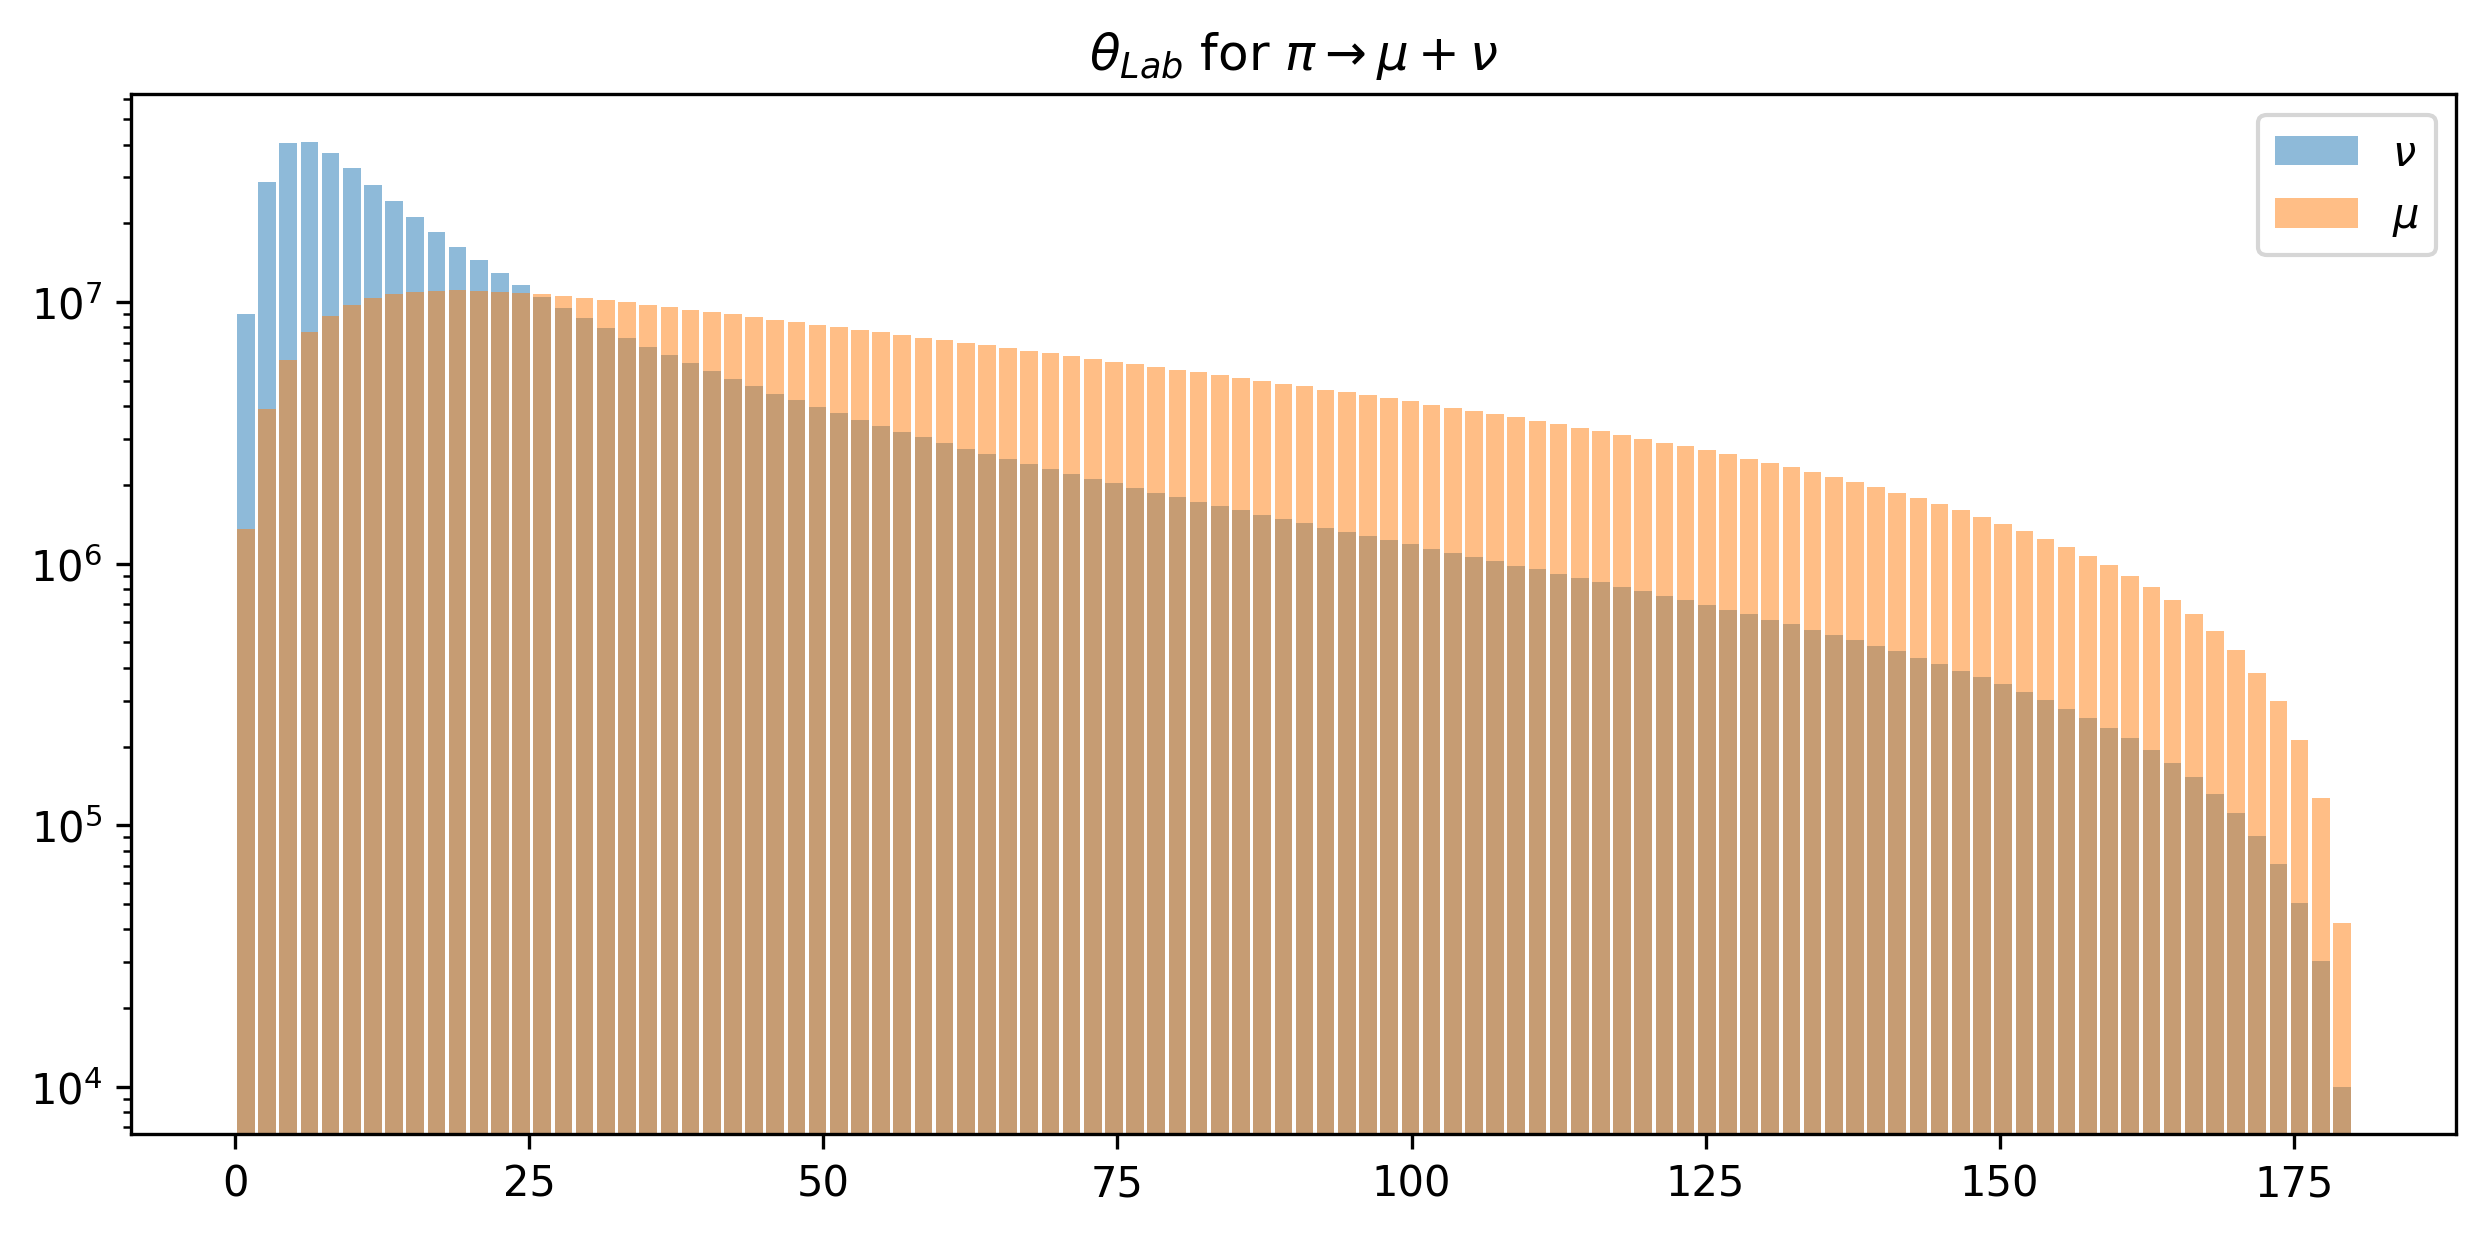

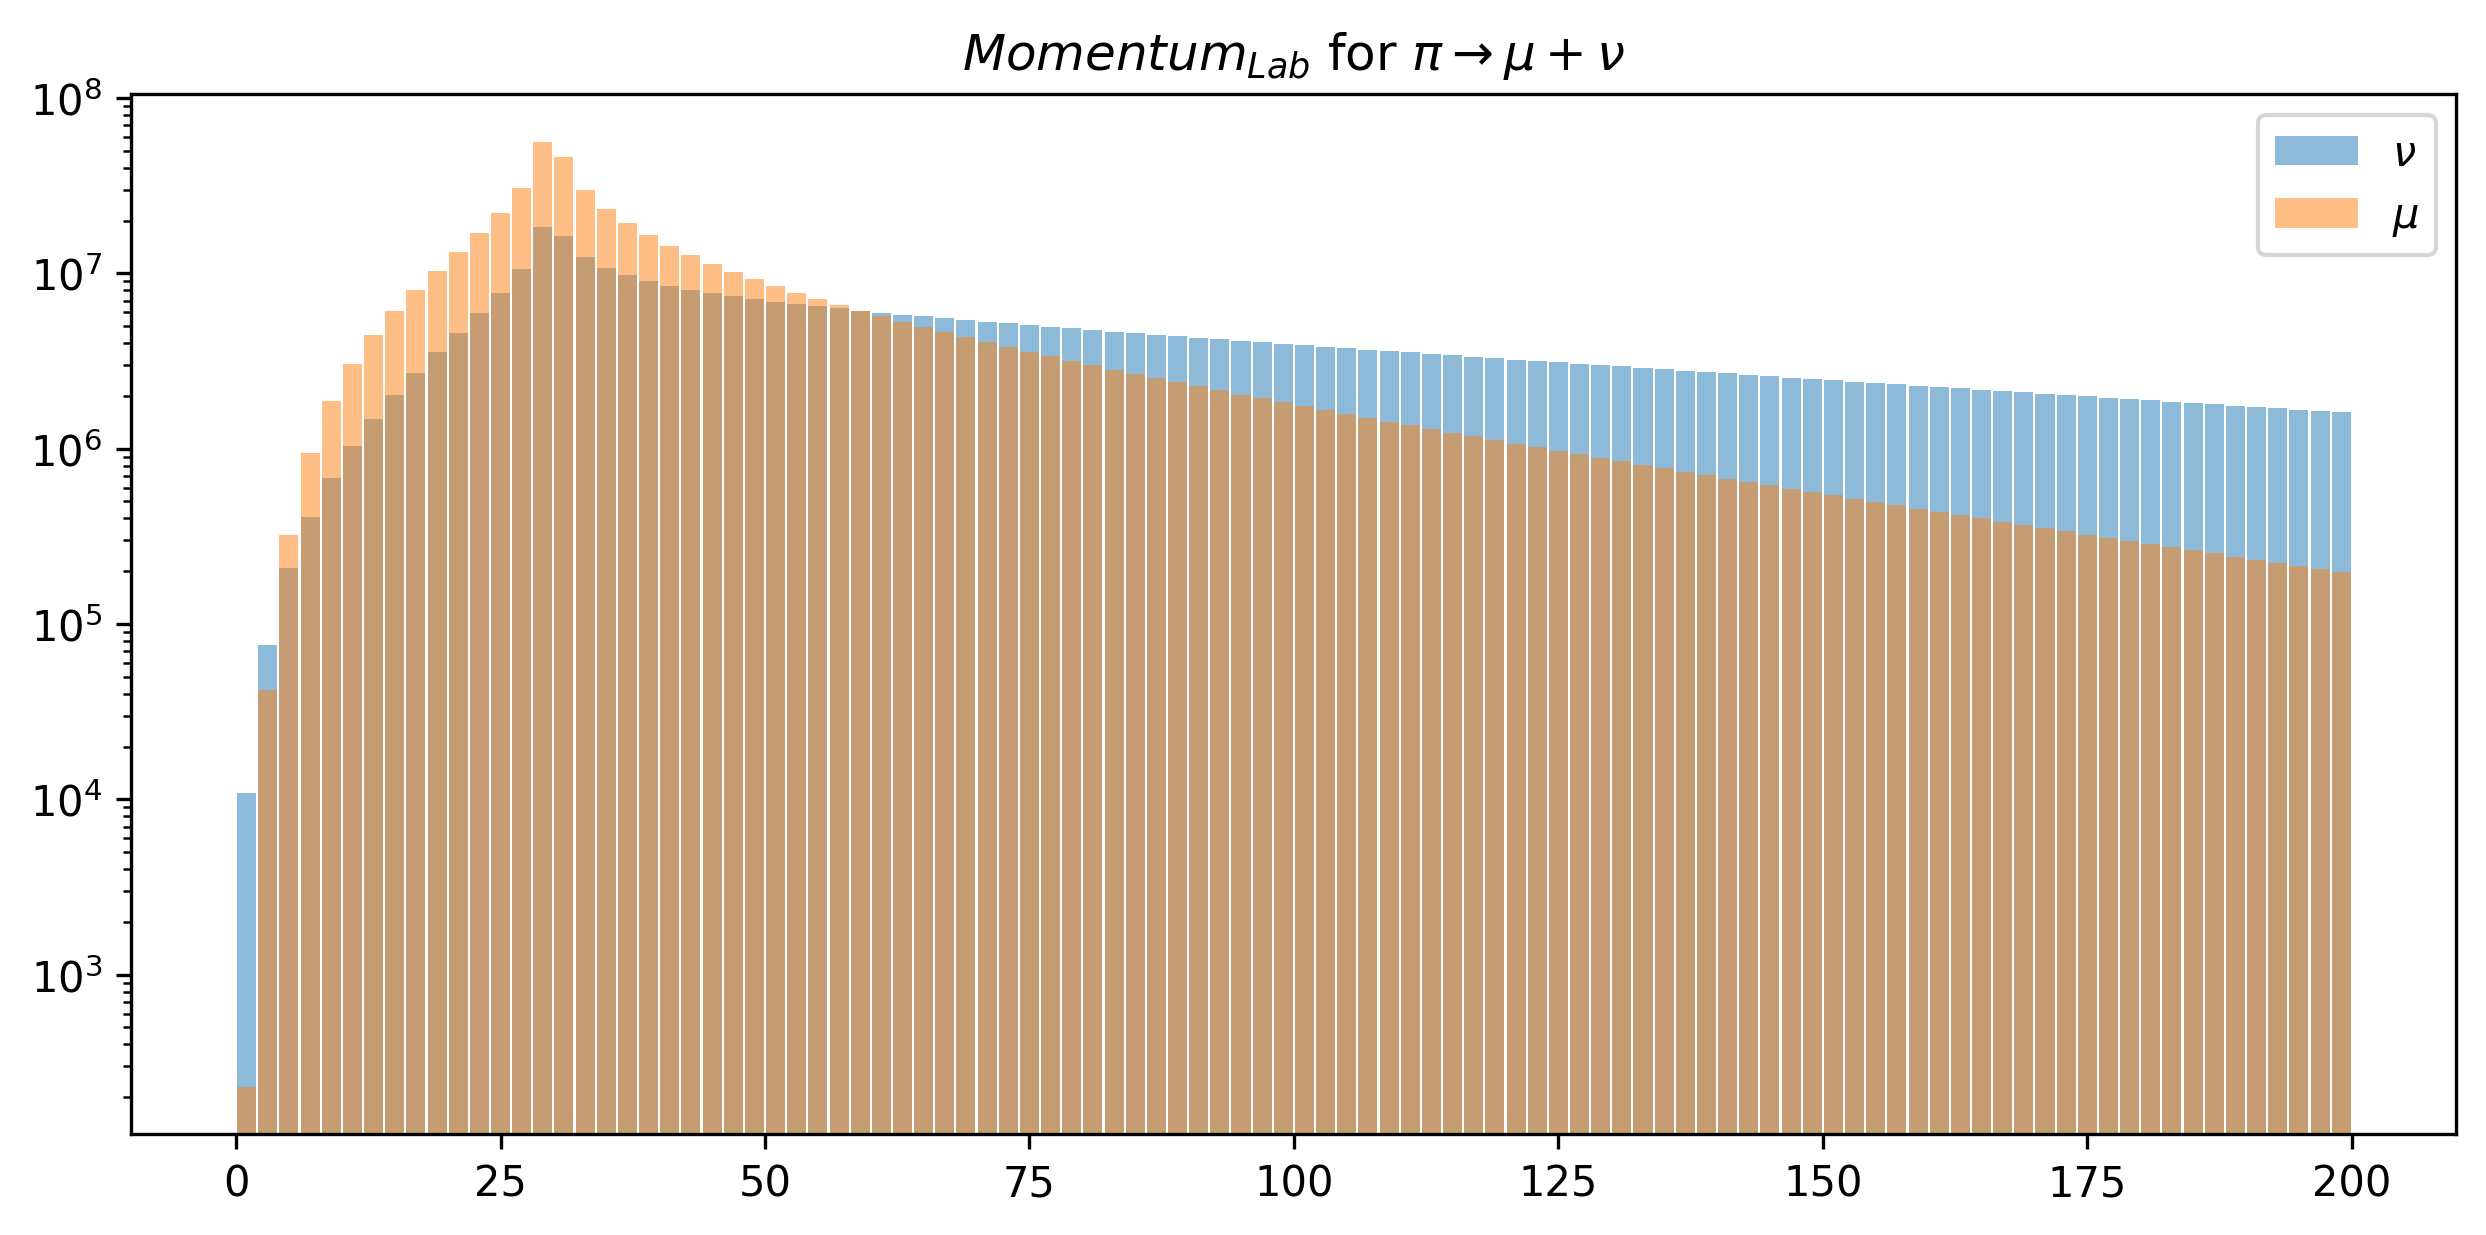

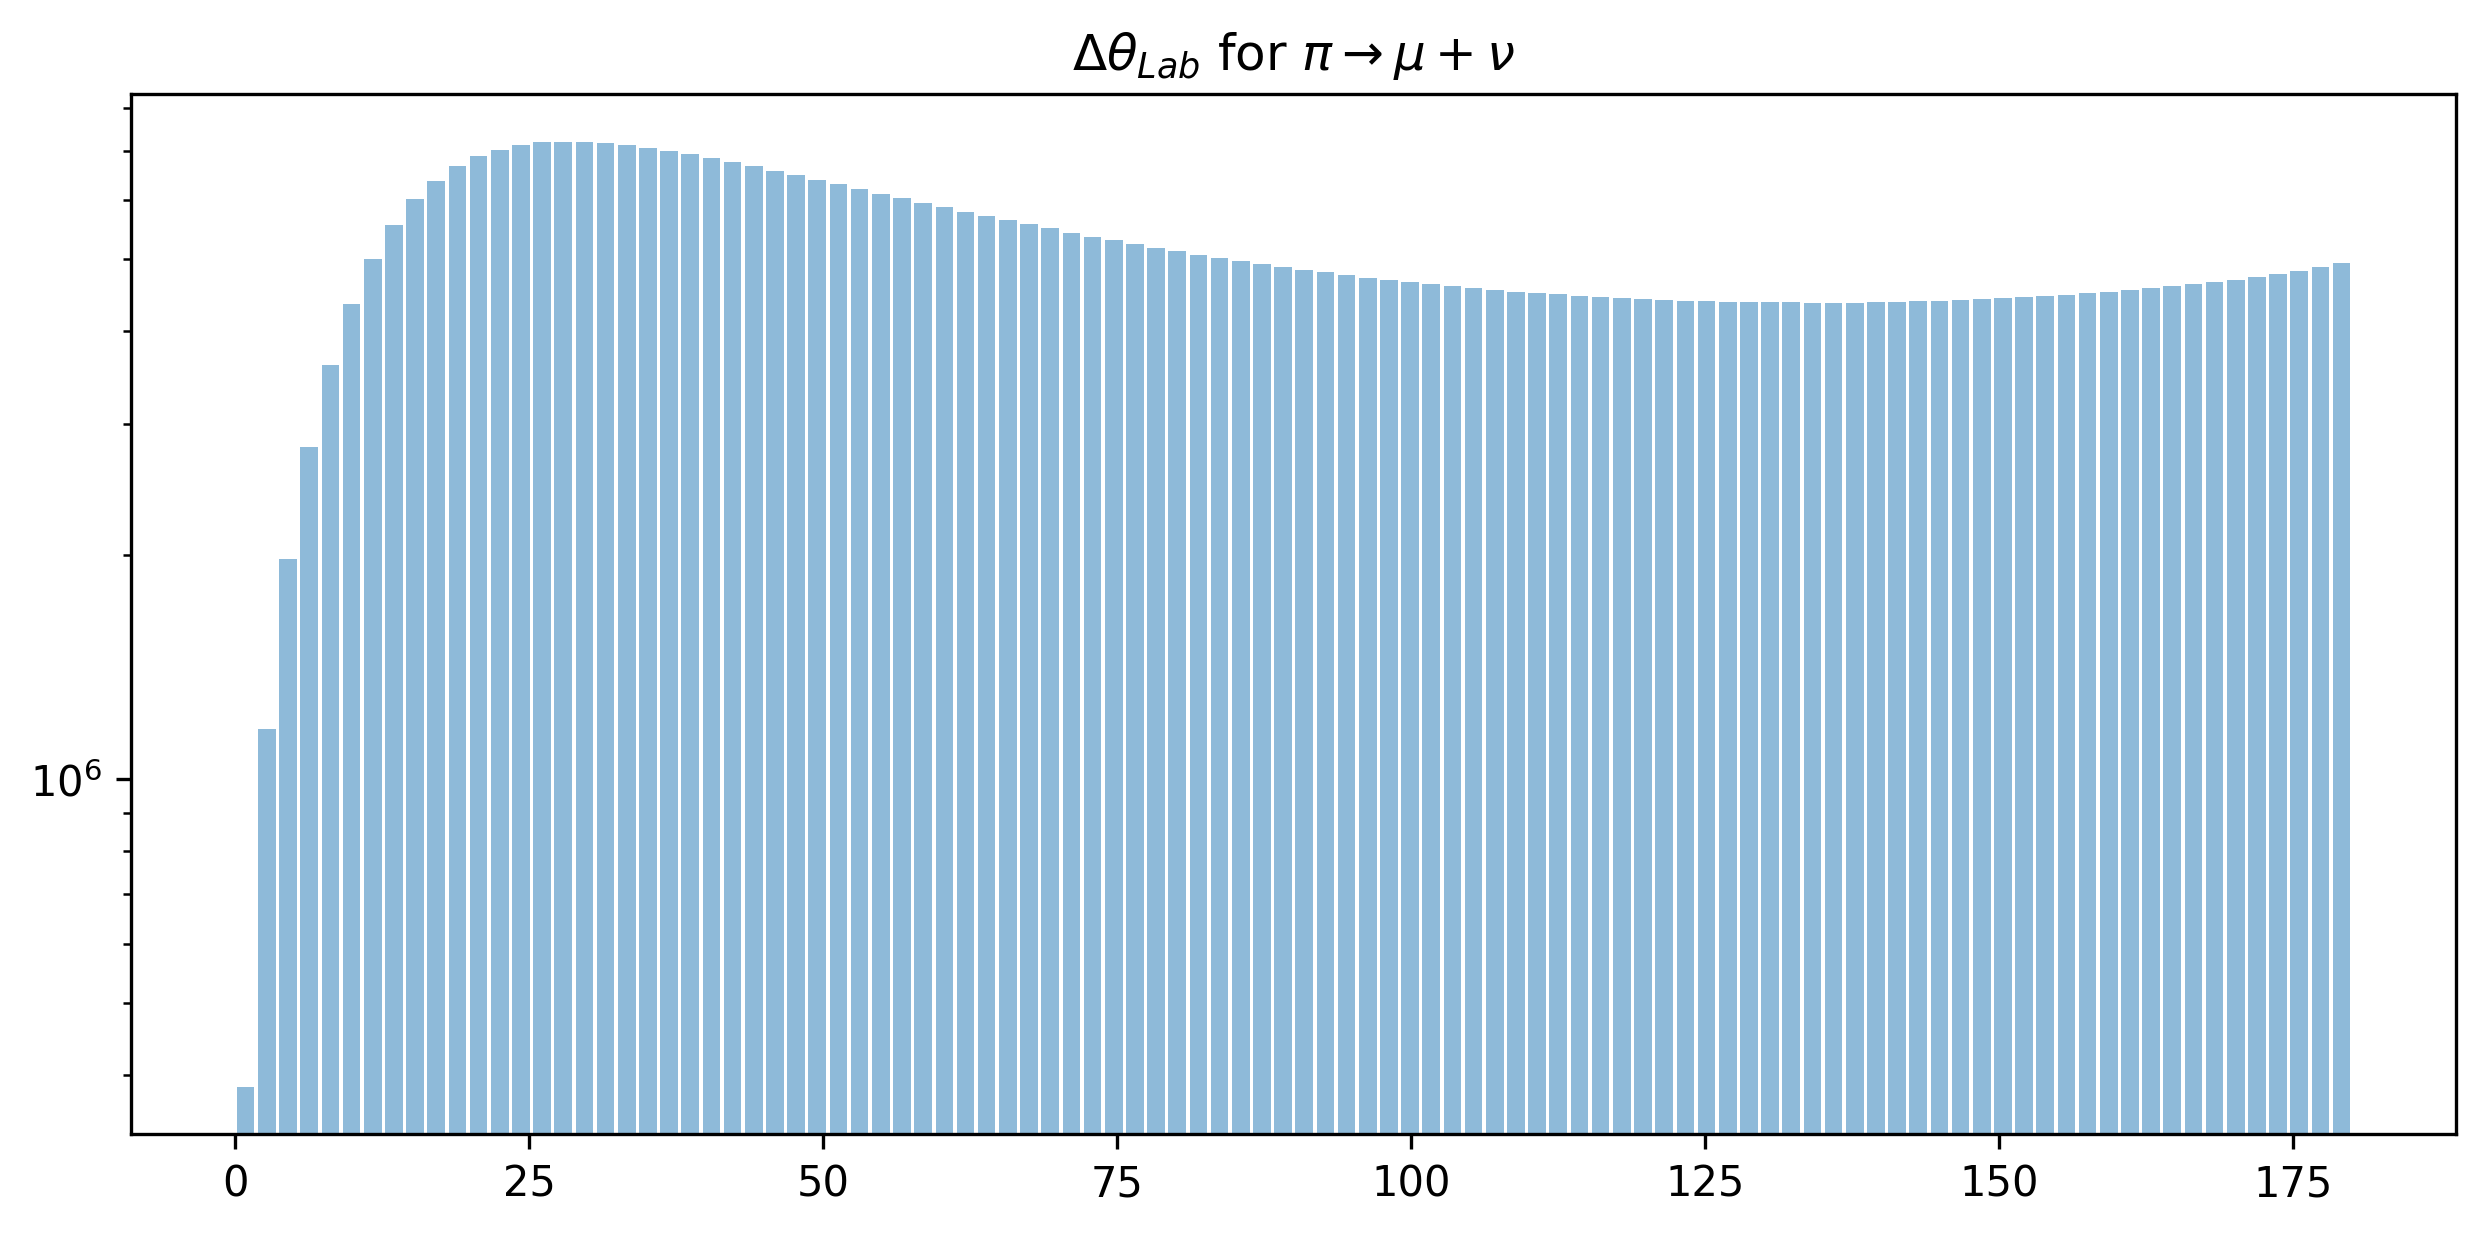

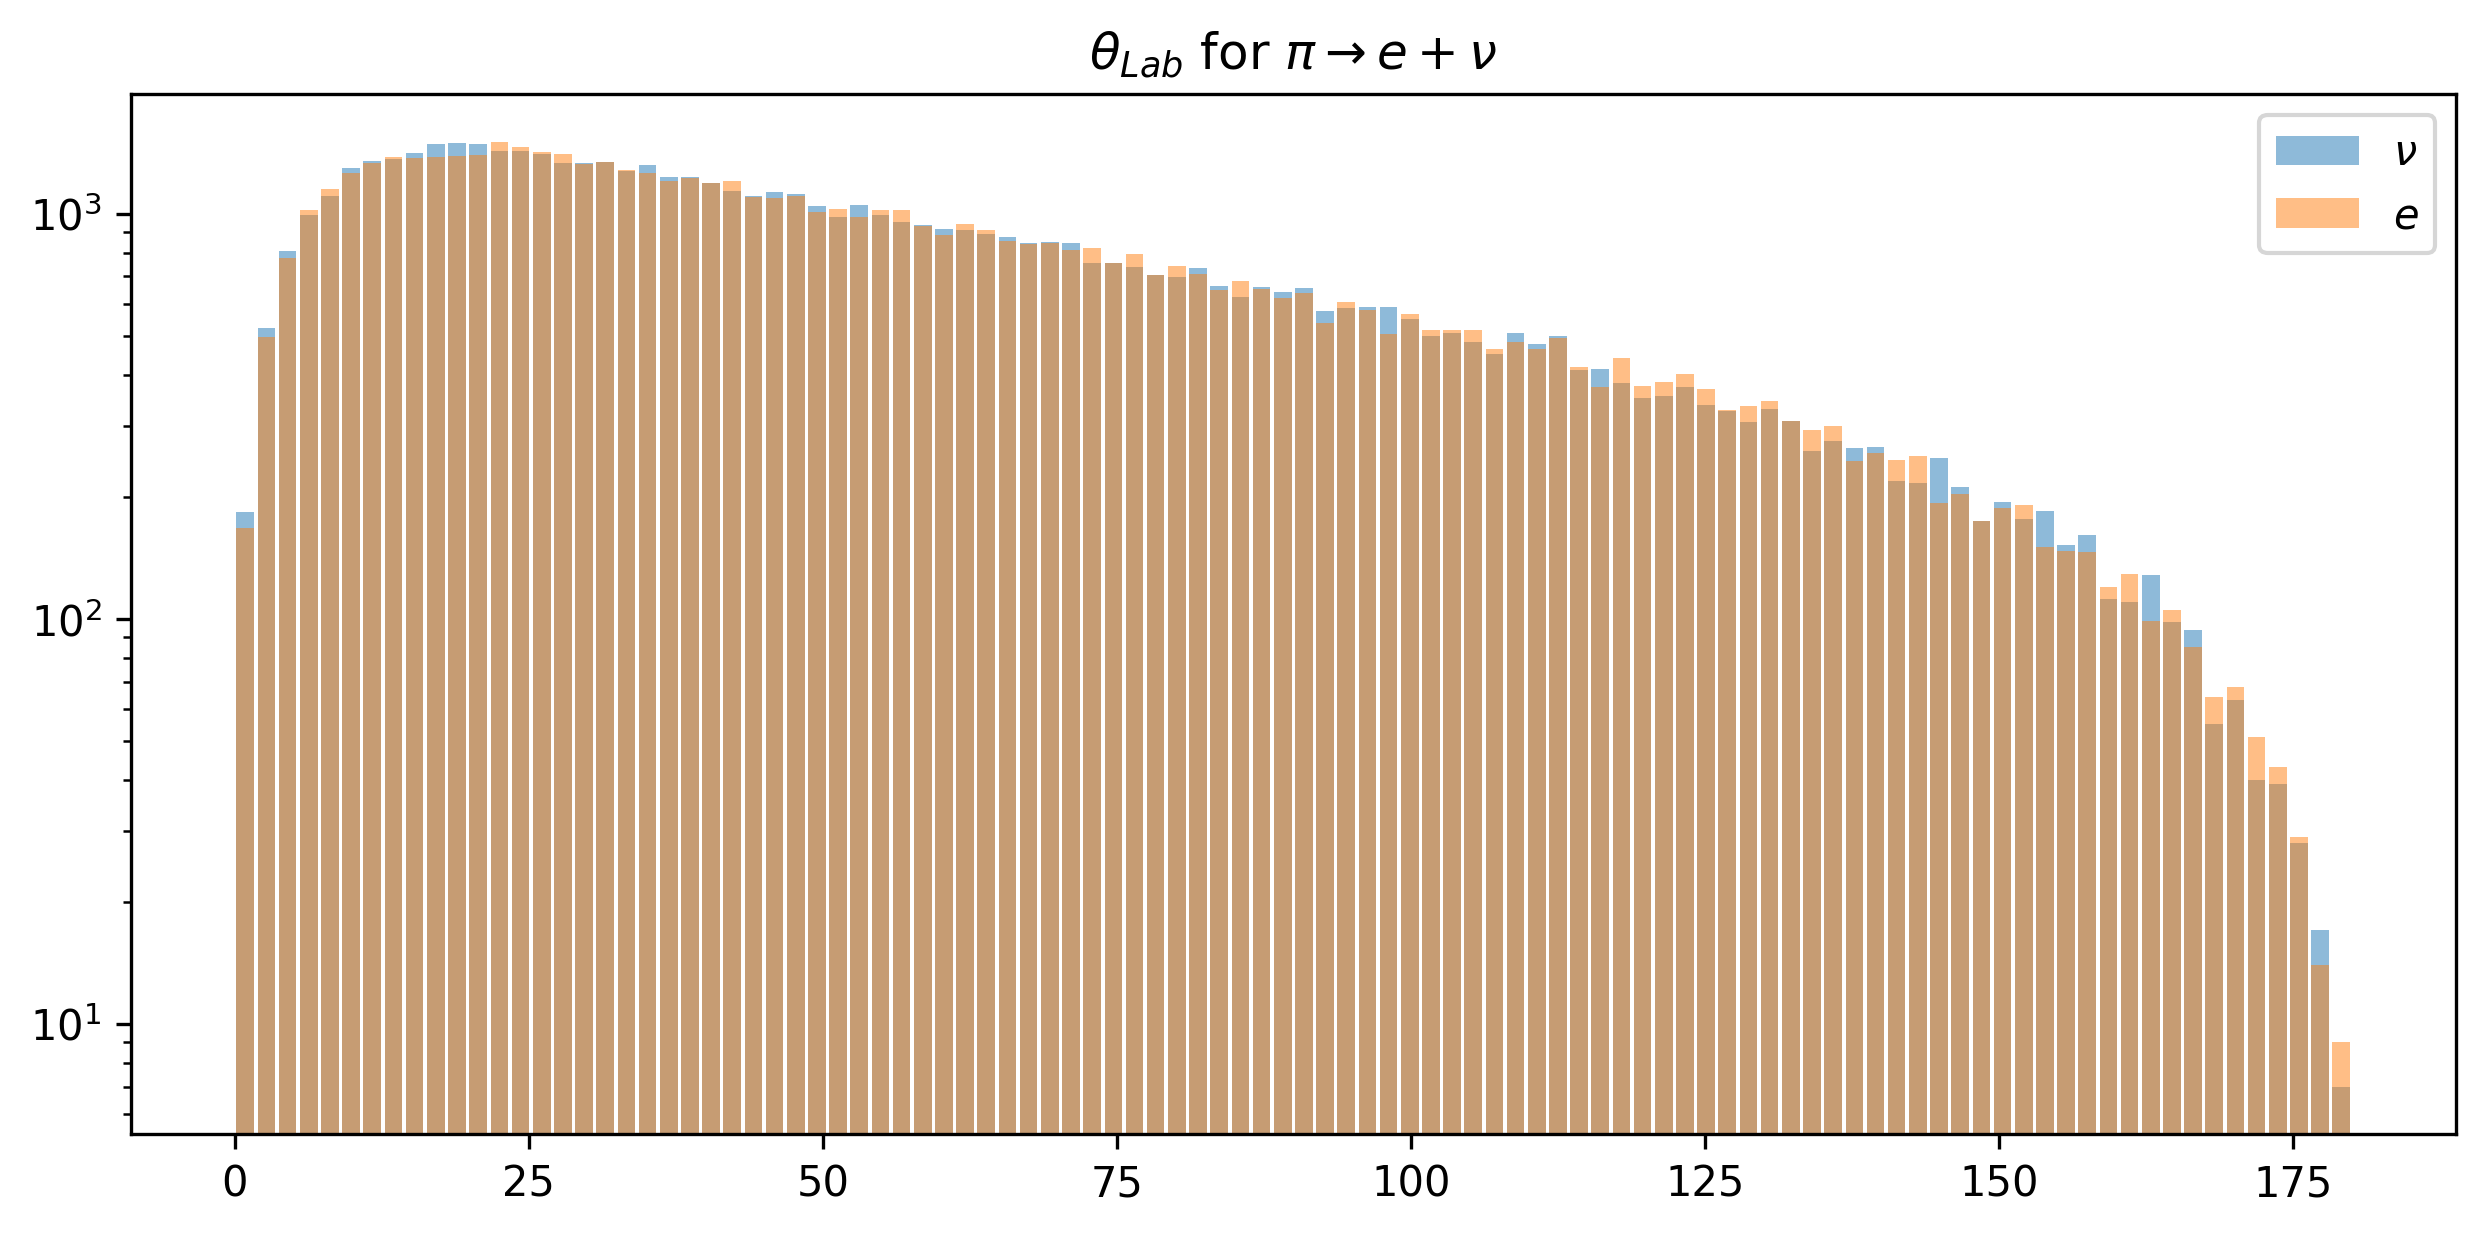

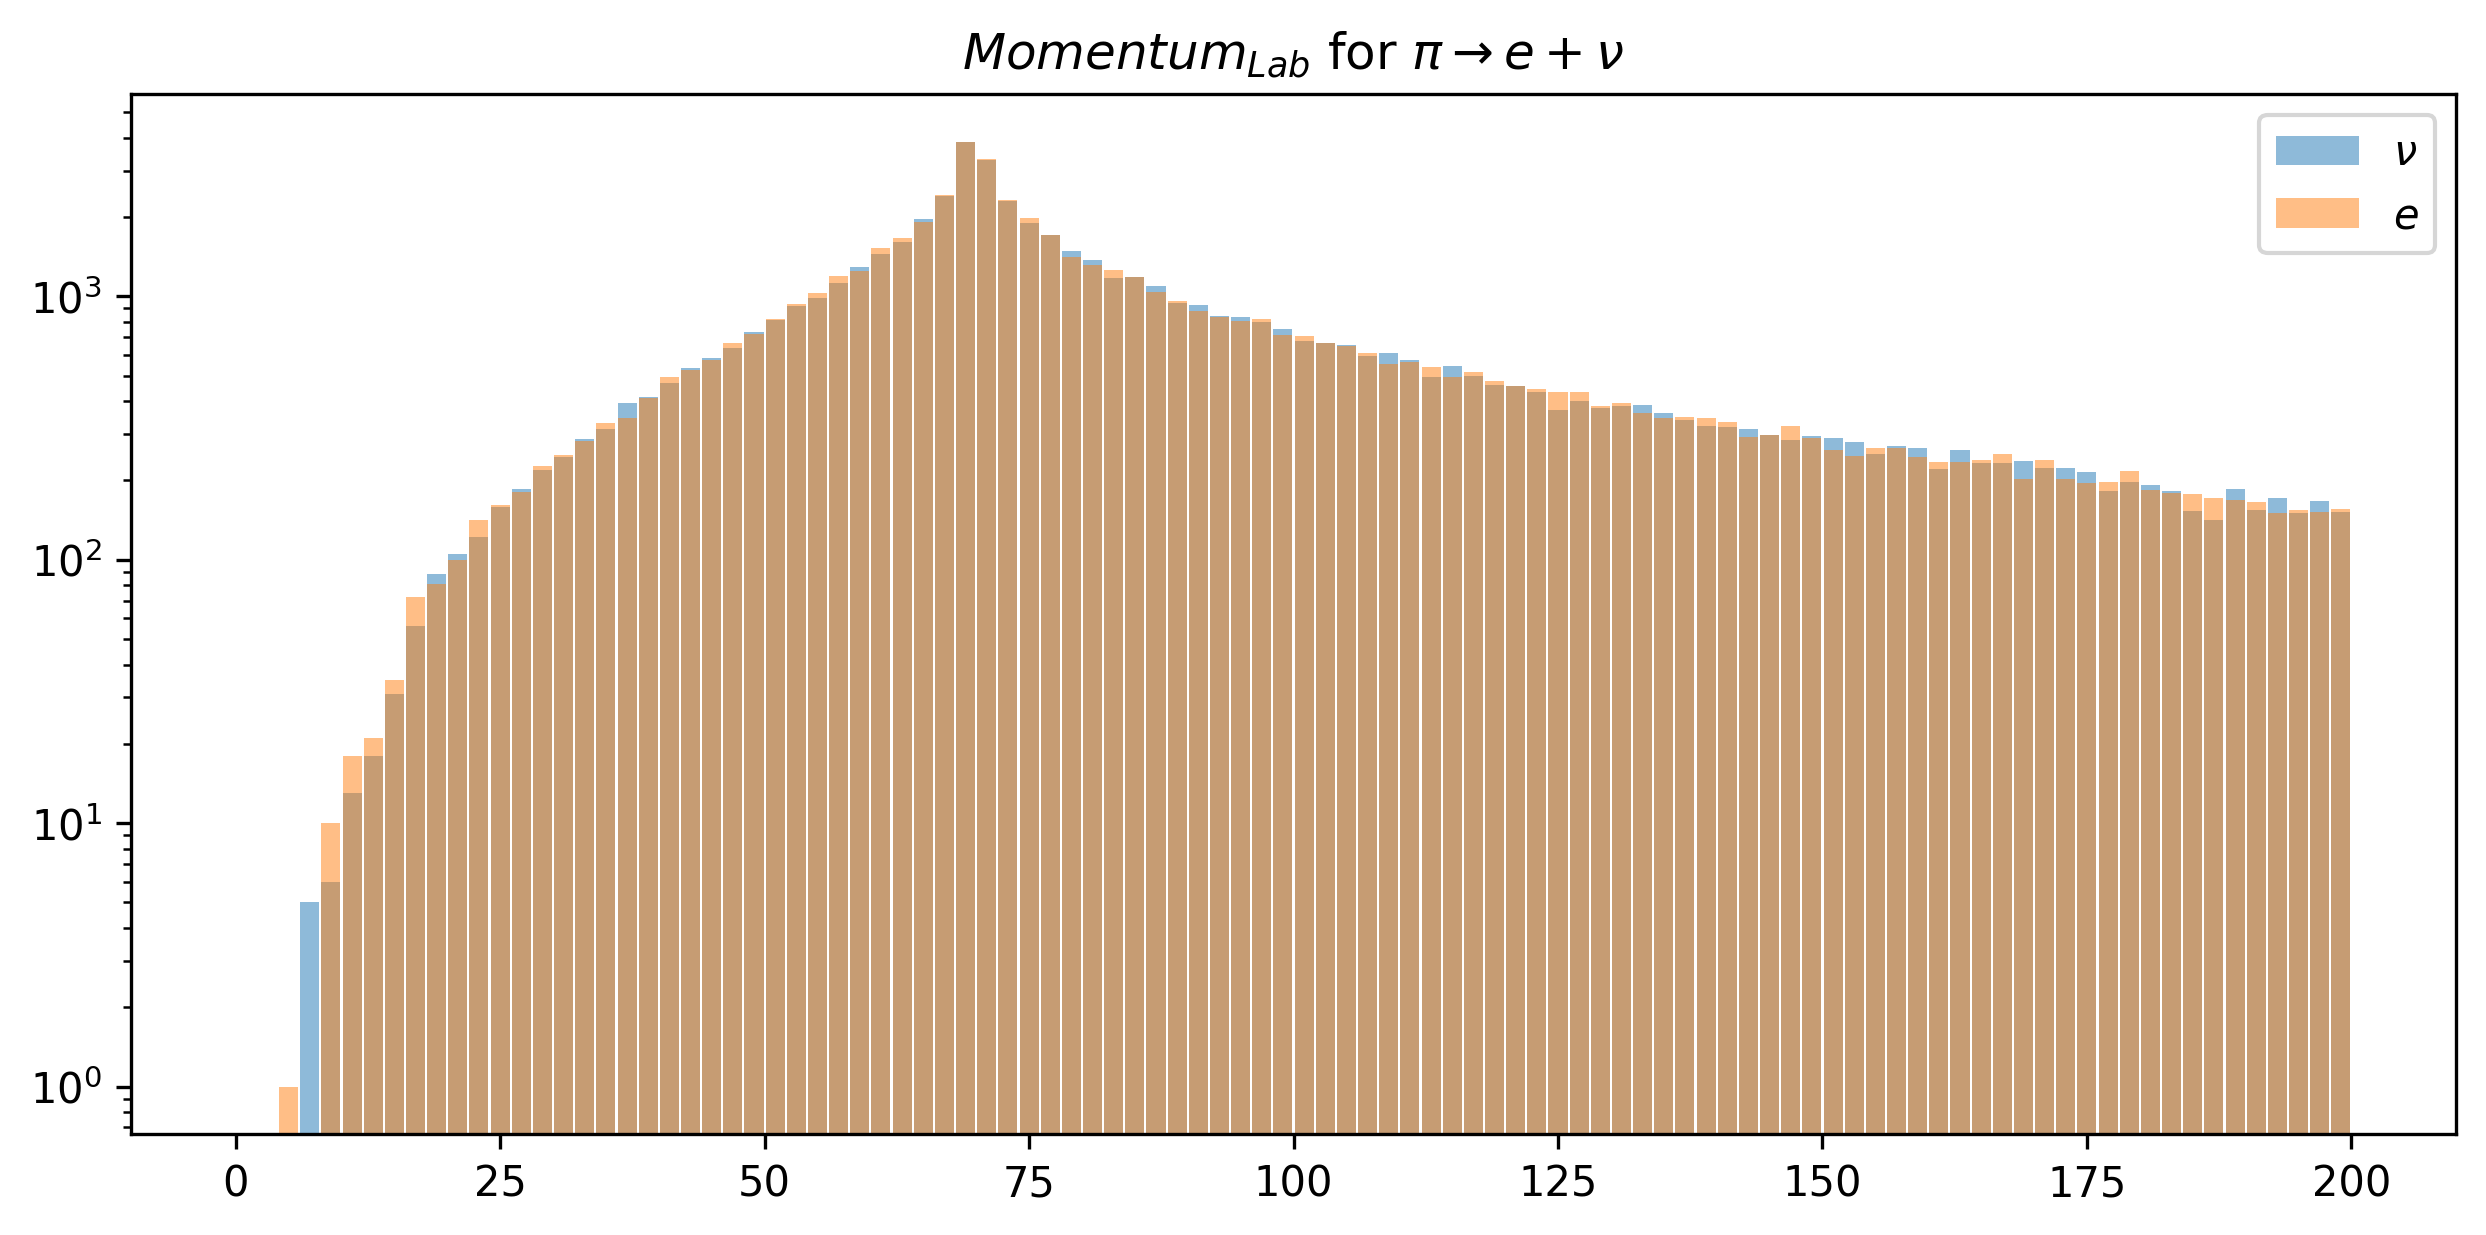

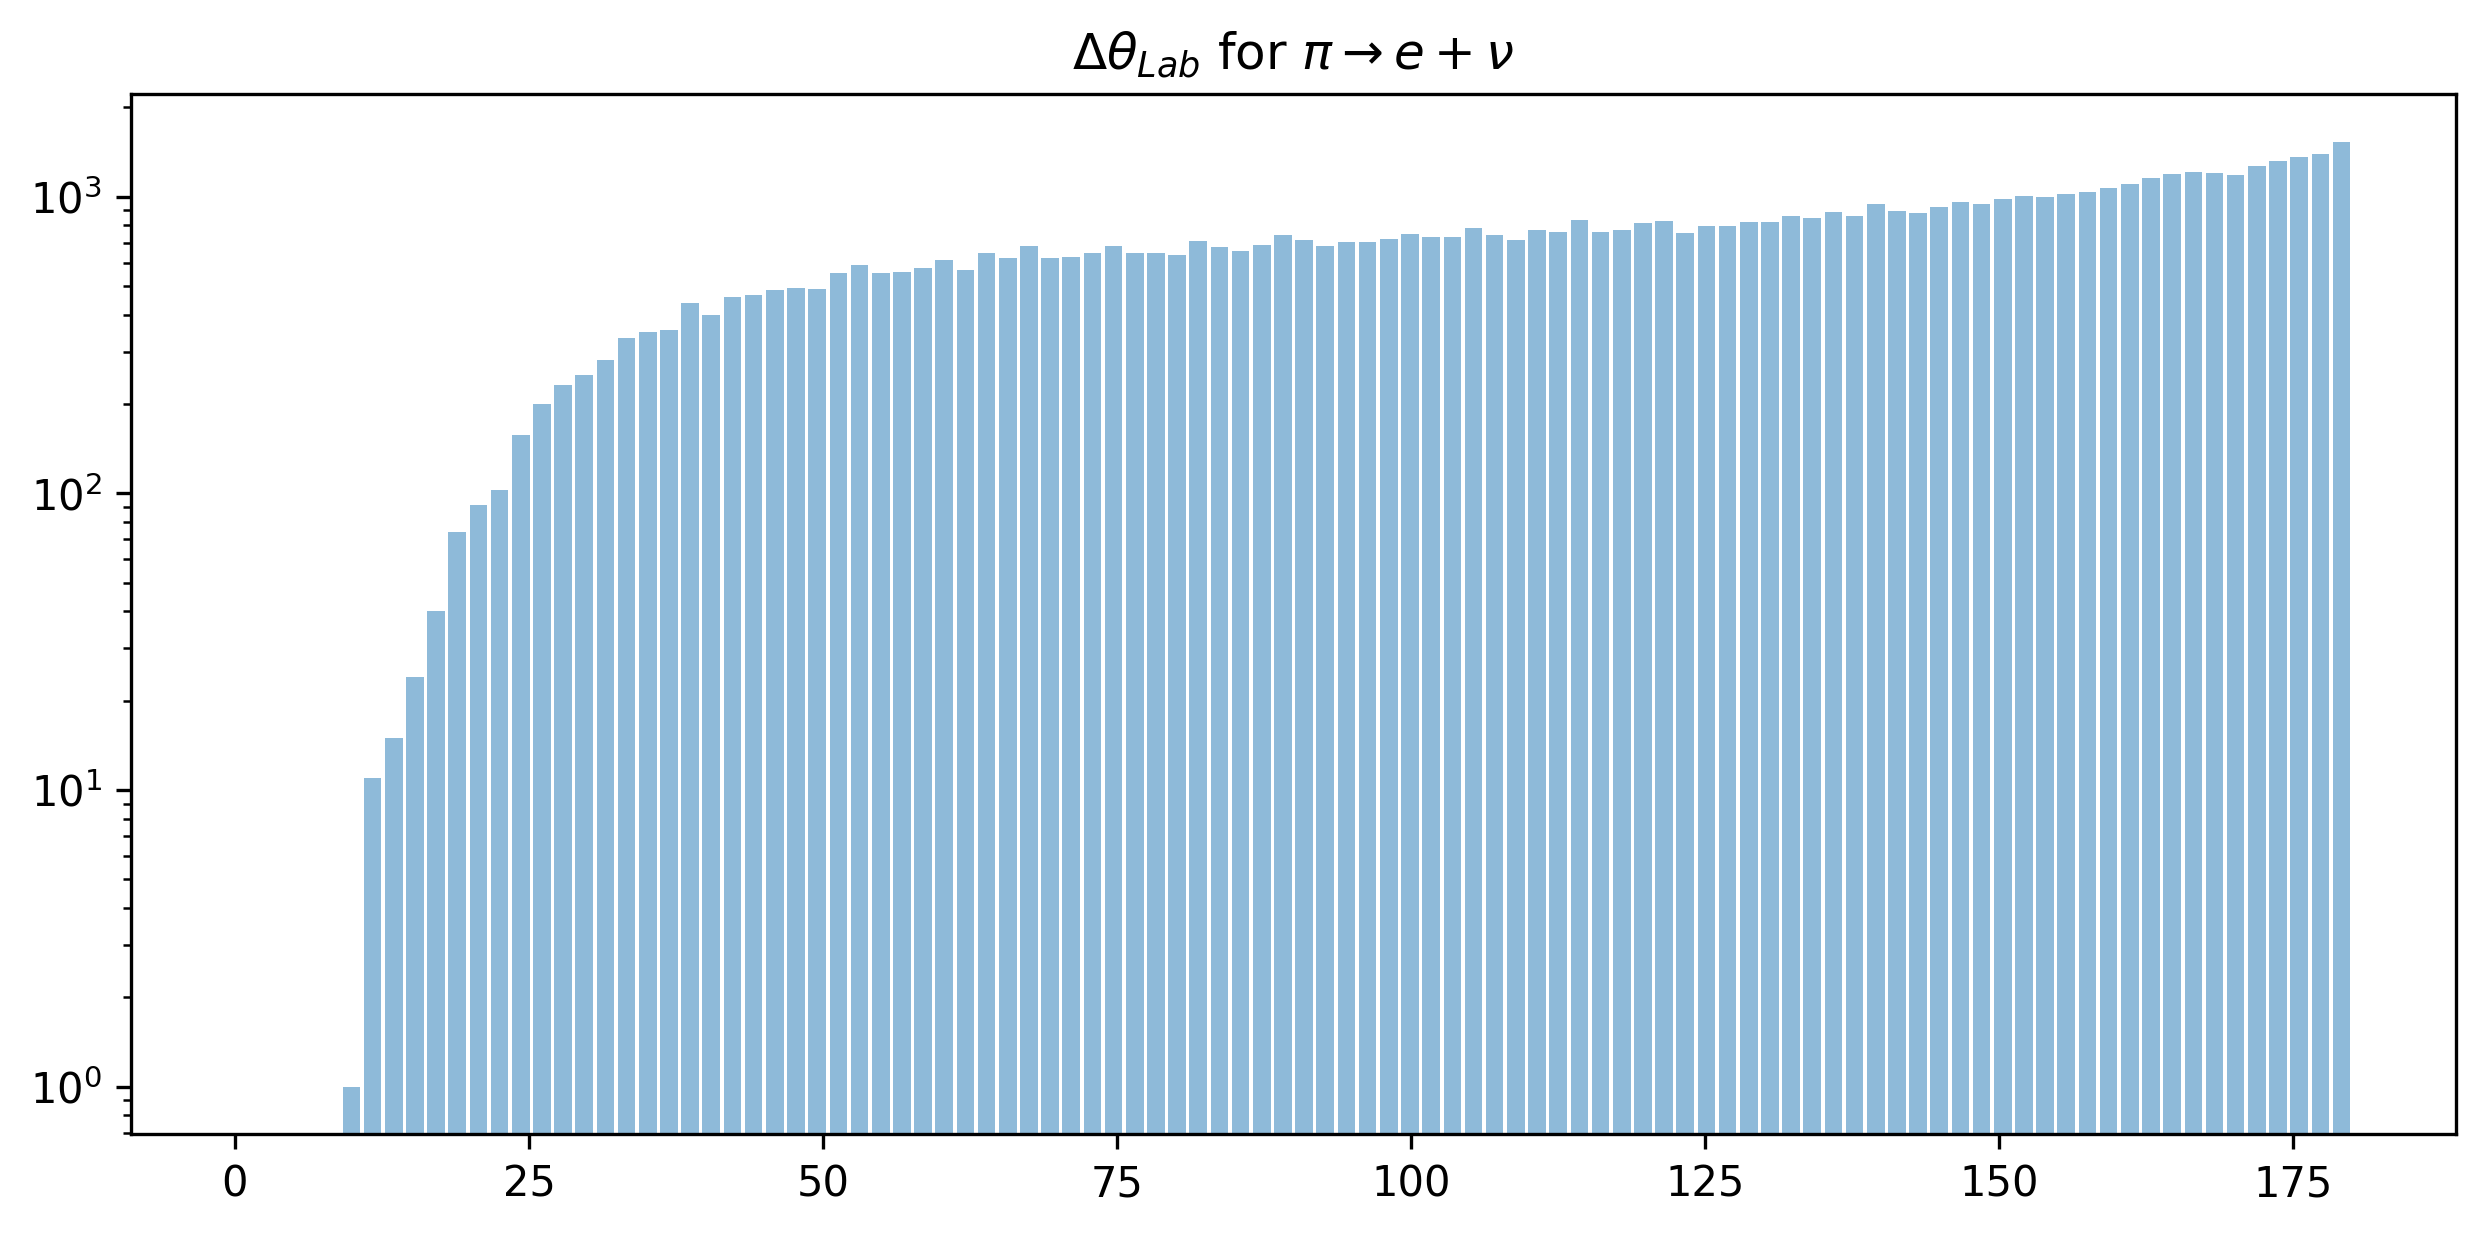

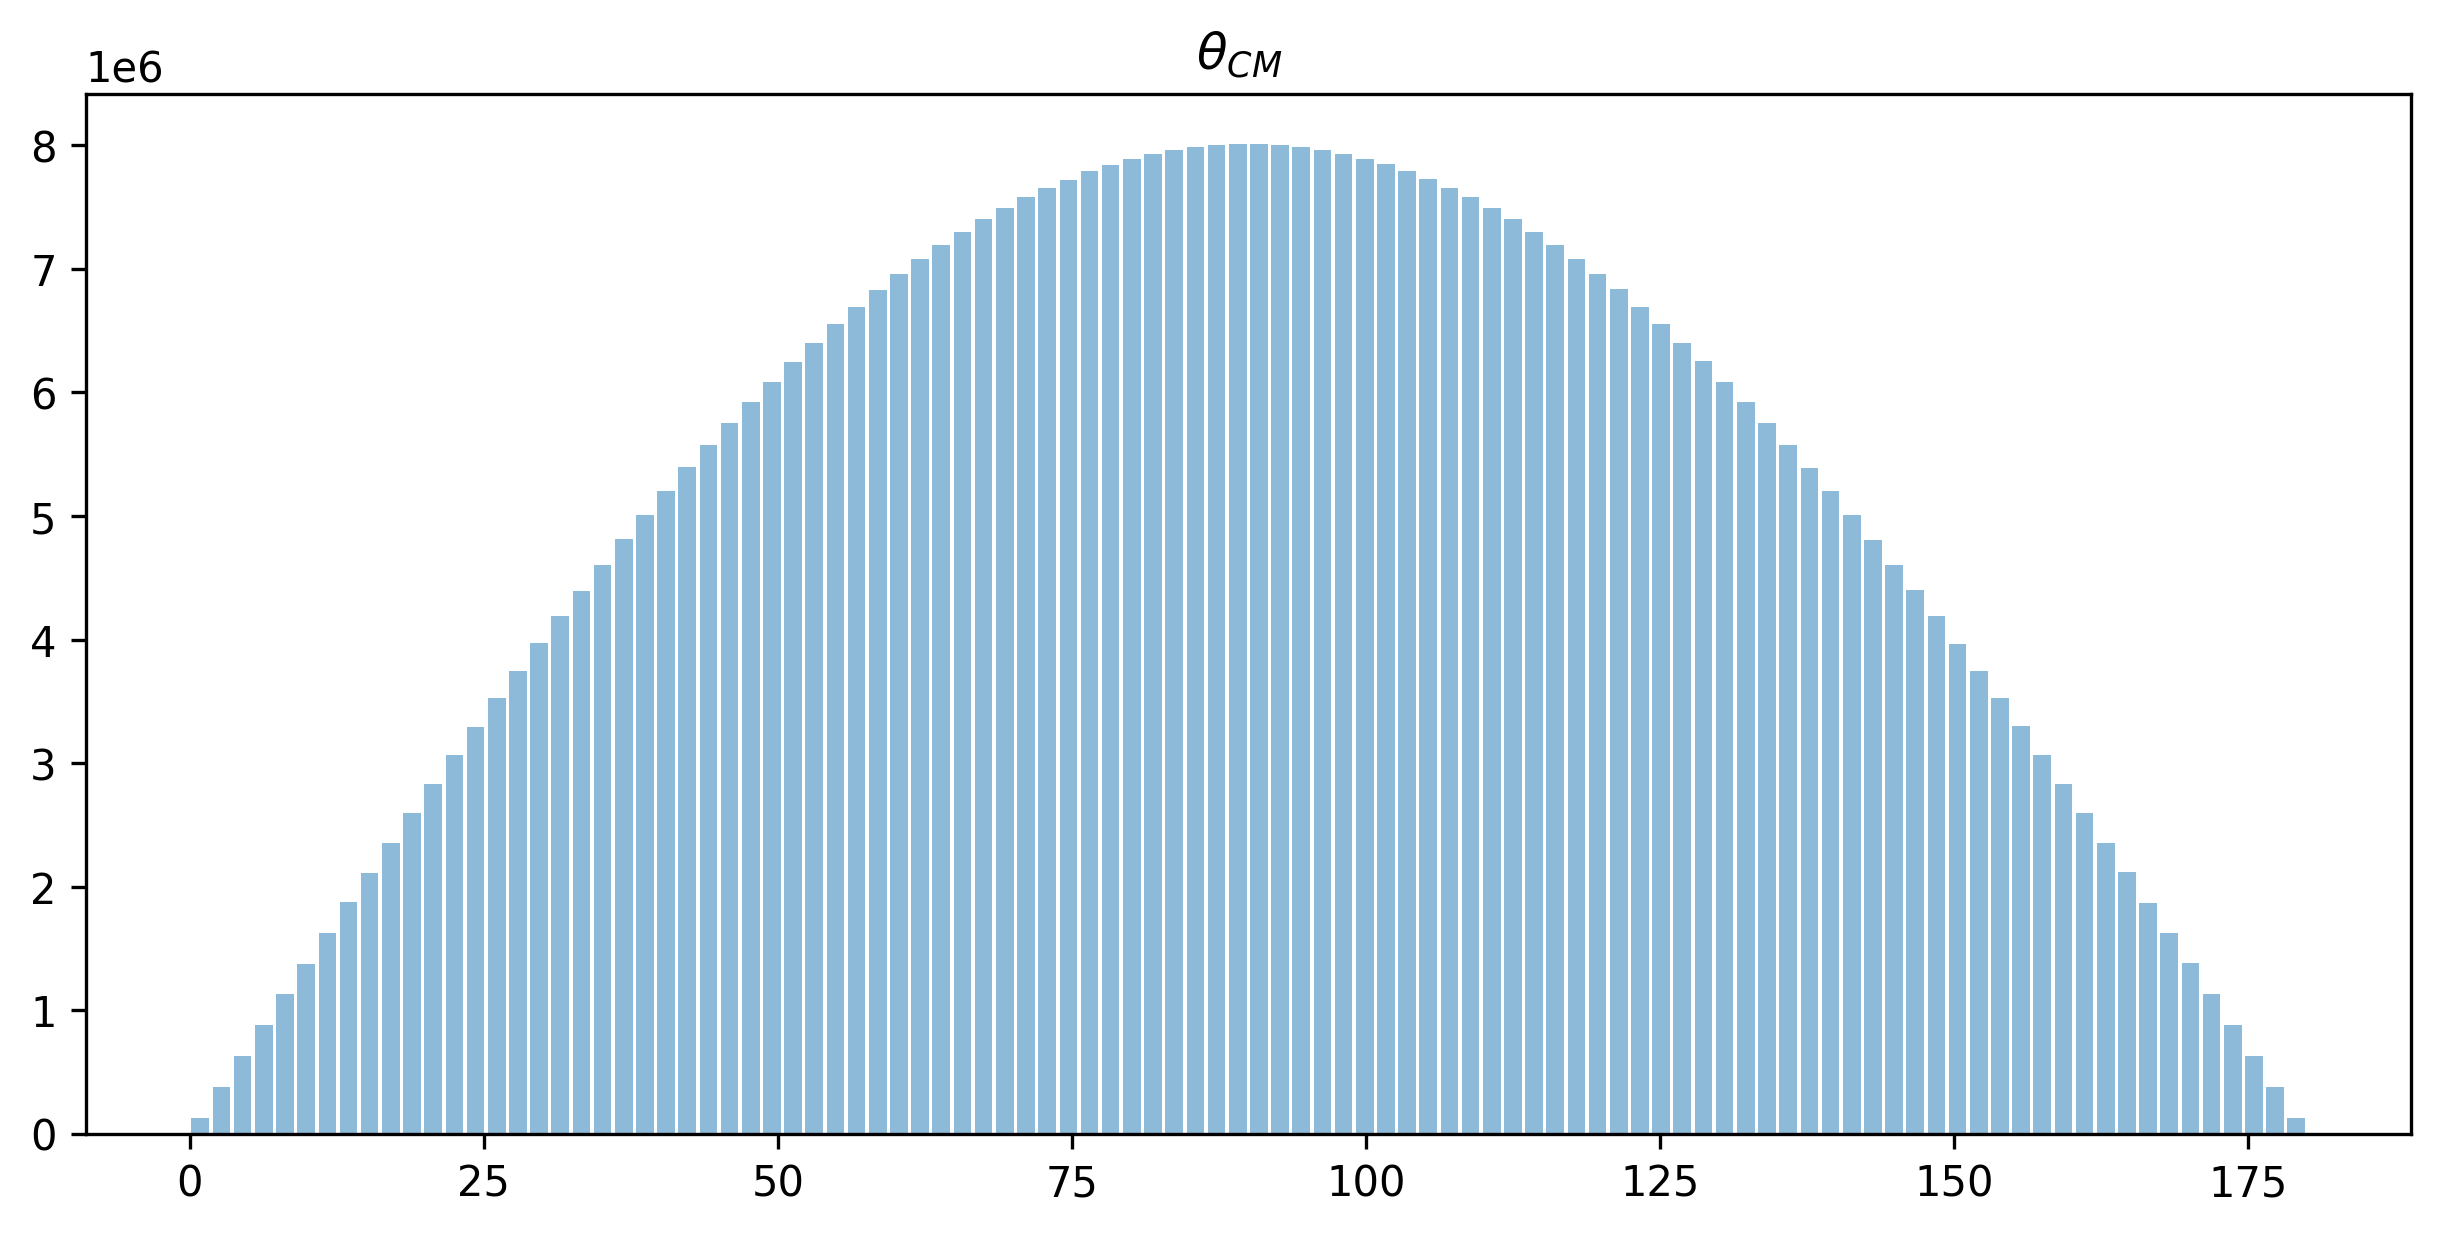

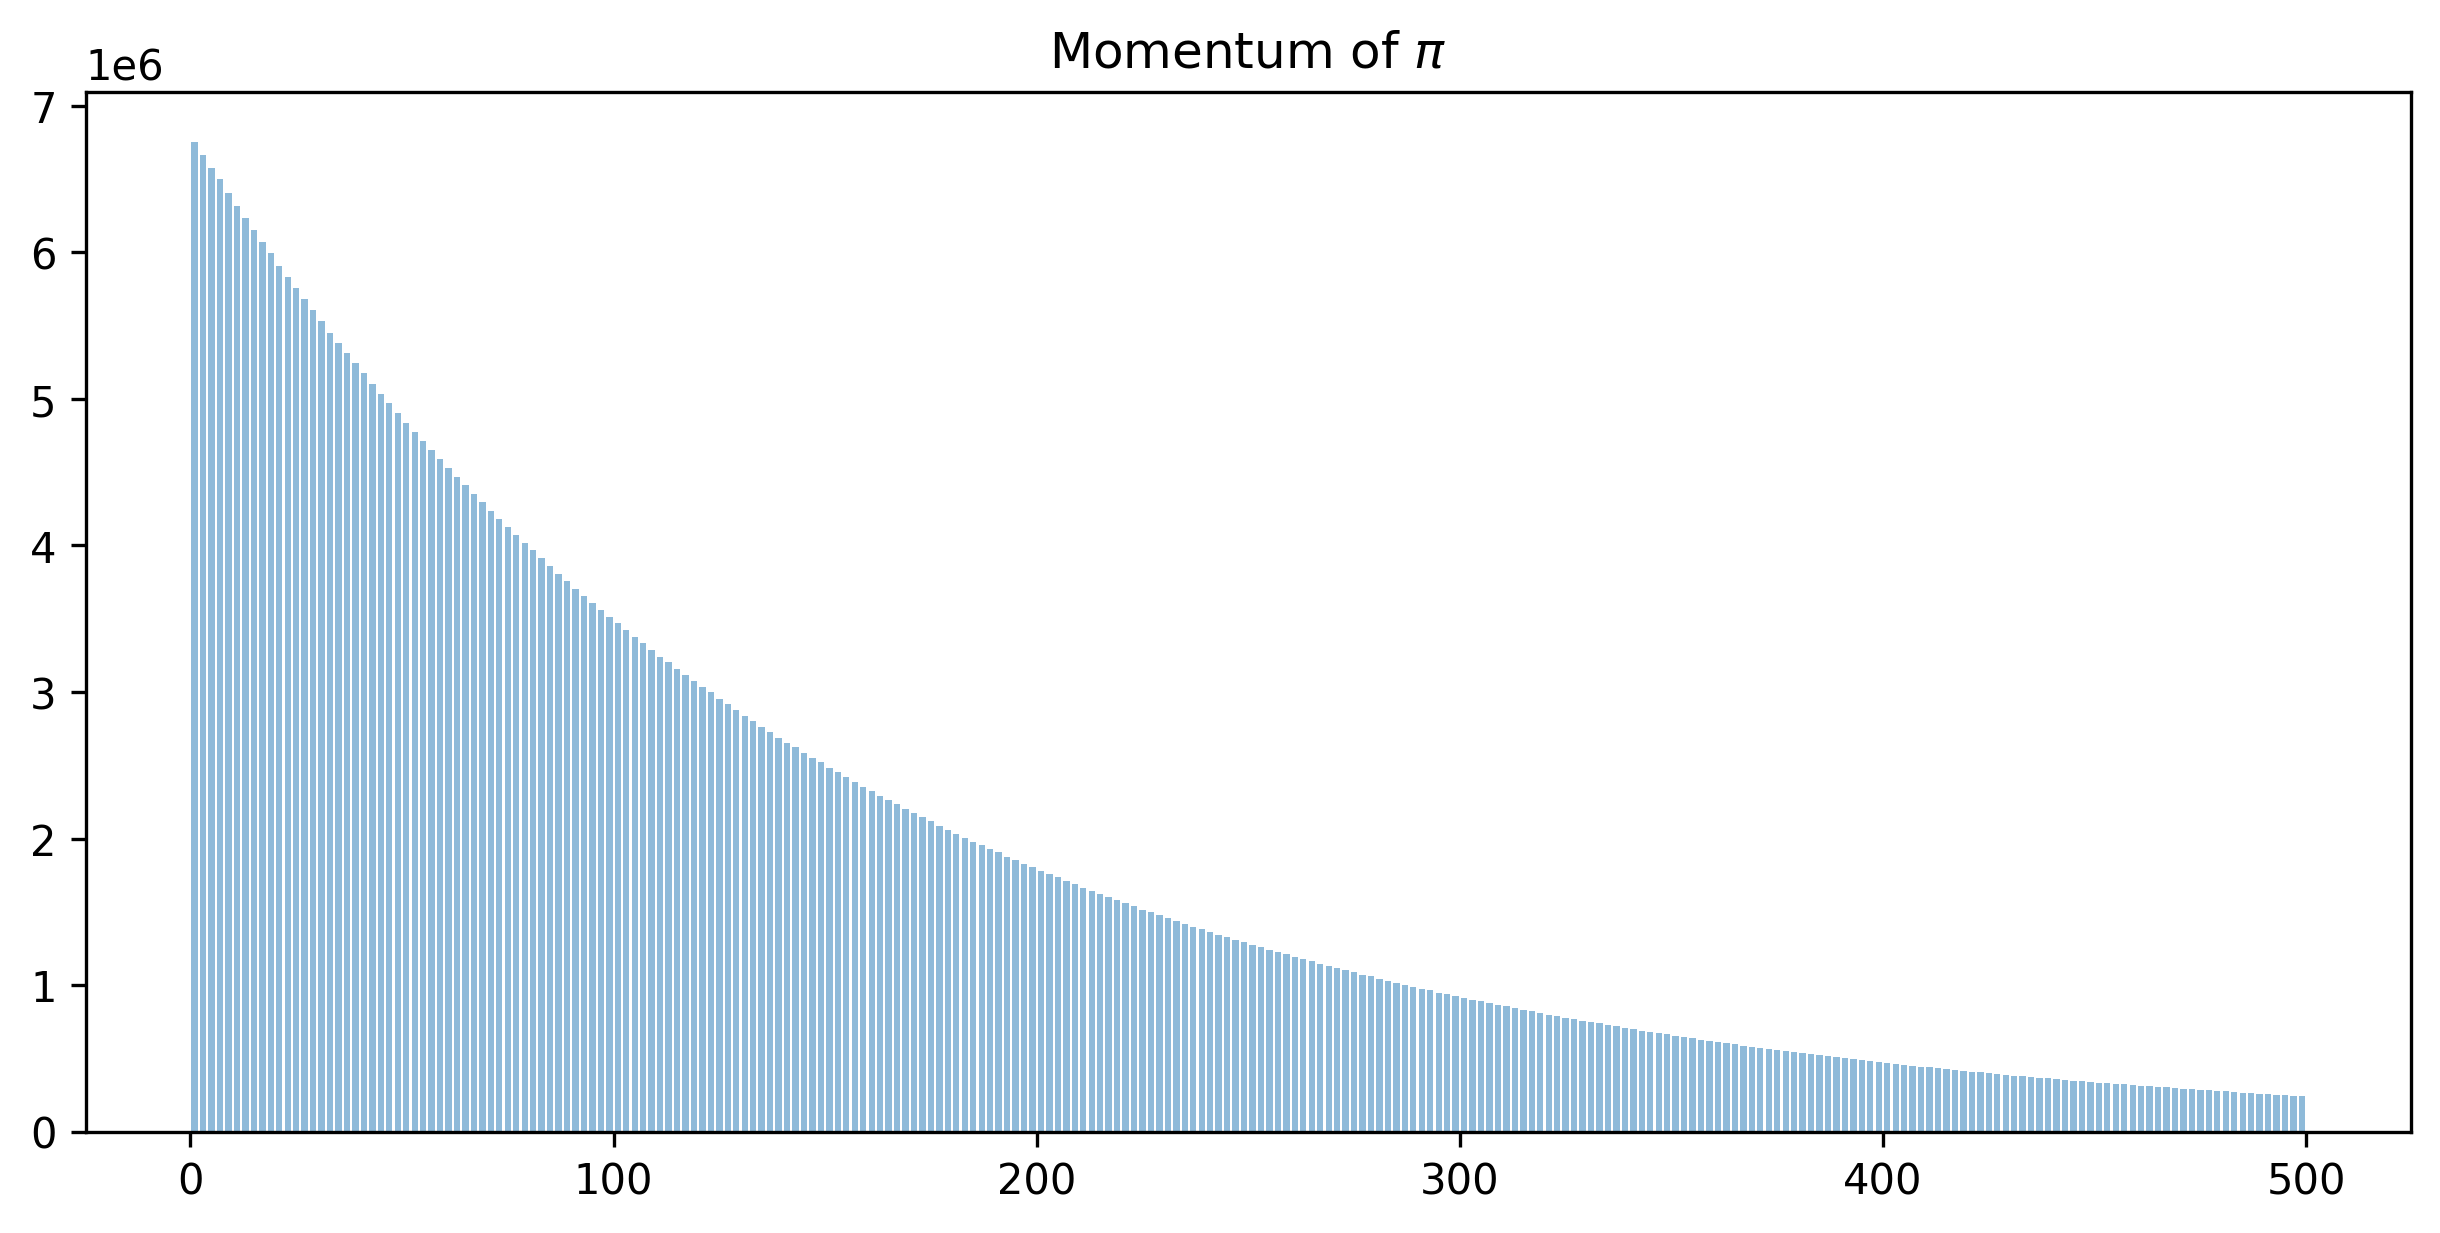

In [4]:
processName=["$\\pi \\to \\mu + \\nu$","$\\pi \\to e + \\nu$"]
daughtersName=["$\\mu$","$e$"]


for i in range(0,2):
    #a->momC
    plt.figure(figsize=(10,4.5),dpi=300)
    plt.bar(thetaBincenters,c0[i].cpu(),width=1.5,alpha=0.5,label="$\\nu$")
    plt.bar(thetaBincenters,e0[i].cpu(),width=1.5,alpha=0.5,label=daughtersName[i])
    plt.legend()
    plt.yscale("log")
    plt.title(f"$\\theta_{{Lab}}$ for {processName[i]}")
    plt.yscale("log")
    plt.figure(figsize=(10,4.5),dpi=300)
    plt.bar(DaughterMomentumBincenters,d0[i].cpu(),width=1.8,alpha=0.5,label="$\\nu$")
    plt.bar(DaughterMomentumBincenters,a0[i].cpu(),width=1.8,alpha=0.5,label=daughtersName[i])
    plt.legend()
    plt.yscale("log")
    plt.title(f"$Momentum_{{Lab}}$ for {processName[i]}")
    plt.show()
    plt.figure(figsize=(10,4.5),dpi=300)
    plt.bar(thetaBincenters,h0[i].cpu(),width=1.5,alpha=0.5)
    plt.title(f"$\\Delta \\theta_{{Lab}}$ for {processName[i]}")
    plt.yscale("log")
    plt.show()



plt.figure(figsize=(10,4.5),dpi=300)
plt.bar(thetaBincenters,g0.cpu(),width=1.5,alpha=0.5)
plt.title(f"$\\theta_{{CM}}$  ")
plt.show()

plt.figure(figsize=(10,4.5),dpi=300)
plt.bar(ParentMomentumBincenters,b0.cpu(),width=1.5,alpha=0.5)
plt.title(f"Momentum of $\\pi$ ")
plt.show()
